# Data Visualization and Exploration

In [3]:
!pip install pyedflib silx h5py numpy


Defaulting to user installation because normal site-packages is not writeable



[notice] A new release of pip is available: 25.1.1 -> 26.0.1
[notice] To update, run: C:\Users\ritaw\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


## para abrir um só

In [30]:
from silx.io import h5py_utils

h5_path = "../Dataset_hdf5/chb06/chb06_01.h5"

with h5py_utils.File(h5_path, "r") as f:
    print(list(f.keys()))  # see what's inside

    signals = f["signals"][:]          # (channels, time)
    fs = f["sampling_rate"][()]
    ch_names = f["channel_names"][:]
    intervals = f["seizure_intervals"][:]

    # Convert bytes → strings
    ch_names = [ch.decode() for ch in ch_names]

print(signals.shape)
print(fs)
print(ch_names)
print(intervals)

['channel_names', 'sampling_rate', 'seizure_intervals', 'signals']
(23, 3693312)
256.0
['FP1-F7', 'F7-T7', 'T7-P7', 'P7-O1', 'FP1-F3', 'F3-C3', 'C3-P3', 'P3-O1', 'FP2-F4', 'F4-C4', 'C4-P4', 'P4-O2', 'FP2-F8', 'F8-T8', 'T8-P8-0', 'P8-O2', 'FZ-CZ', 'CZ-PZ', 'P7-T7', 'T7-FT9', 'FT9-FT10', 'FT10-T8', 'T8-P8-1']
[[ 441344  444928]
 [1910016 1913856]
 [3462400 3466240]]


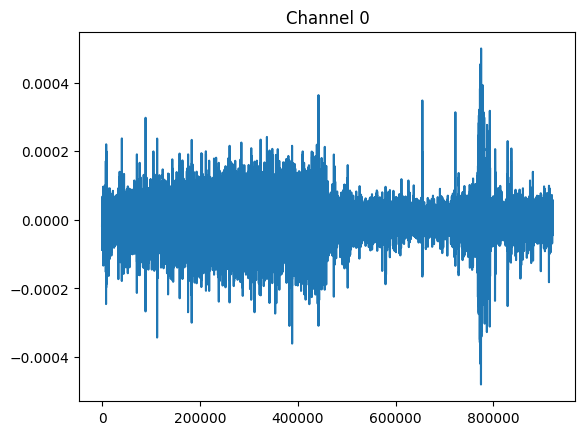

In [27]:
import matplotlib.pyplot as plt

plt.plot(signals[0][:921600])  # first channel, first 1000 samples
plt.title("Channel 0")
plt.show()

### CORRETO

In [70]:
import re

def parse_chbmit_summary(summary_path):
    seizures_dict = {}

    with open(summary_path, "r", encoding="latin1") as f:
        text = f.read()

    blocks = text.split("File Name:")

    for block in blocks:
        if ".edf" not in block:
            continue

        file_match = re.search(r"(chb\d+_\d+\.edf)", block)
        if not file_match:
            continue

        file_name = file_match.group(1)

        seizures = []

        # ---------------------------------------------------
        # CASE 1: numbered seizures (Seizure 1, Seizure 2...)
        # ---------------------------------------------------
        starts_num = re.findall(r"Seizure\s*\d+\s*Start Time:\s*(\d+)", block)
        ends_num   = re.findall(r"Seizure\s*\d+\s*End Time:\s*(\d+)", block)

        if len(starts_num) > 0 and len(ends_num) > 0:
            seizures = [(int(s), int(e)) for s, e in zip(starts_num, ends_num)]

        else:
            # ---------------------------------------------------
            # CASE 2: unnumbered format (single seizure style)
            # ---------------------------------------------------
            start = re.search(r"Seizure Start Time:\s*(\d+)", block)
            end   = re.search(r"Seizure End Time:\s*(\d+)", block)

            if start and end:
                seizures = [(int(start.group(1)), int(end.group(1)))]

        seizures_dict[file_name] = seizures

    return seizures_dict

In [74]:
numero = '01'

In [ ]:
texto = f"../Dataset/chb{numero}/chb{numero}-summary.txt"
seizure_map = parse_chbmit_summary(texto)
seizure_map

In [77]:
import os
import numpy as np
import mne
import h5py

DATASET_PATH = f"../Dataset/chb{numero}"
OUTPUT_PATH = f"../Dataset_hdf5/chb{numero}"

os.makedirs(OUTPUT_PATH, exist_ok=True)


def convert_dataset(seizure_map):
    for file_name, seizures_sec in seizure_map.items():

        edf_path = os.path.join(DATASET_PATH, file_name)
        if not os.path.exists(edf_path):
            print(f"Missing: {edf_path}")
            continue

        print(f"Processing {file_name}")

        # -------------------------
        # Load EDF
        # -------------------------
        raw = mne.io.read_raw_edf(edf_path, preload=True, verbose=False)
        raw.rename_channels(lambda x: x.strip())

        data = raw.get_data().astype(np.float32)   # (channels, samples)
        fs = float(raw.info["sfreq"])
        ch_names = np.array(raw.ch_names, dtype="S")

        # -------------------------
        # Convert seizures (sec → samples)
        # -------------------------
        seizures_samples = np.array(
            [(int(s * fs), int(e * fs)) for s, e in seizures_sec],
            dtype=np.int64
        )

        if seizures_samples.size == 0:
            seizures_samples = np.zeros((0, 2), dtype=np.int64)

        # -------------------------
        # Save HDF5
        # -------------------------
        h5_path = os.path.join(
            OUTPUT_PATH,
            file_name.replace(".edf", ".h5")
        )

        with h5py.File(h5_path, "w") as f:
            f.create_dataset("signals", data=data, compression="gzip")
            f.create_dataset("sampling_rate", data=fs)
            f.create_dataset("channel_names", data=ch_names)
            f.create_dataset("seizure_intervals", data=seizures_samples)

        print(f"Saved → {h5_path} | seizures: {len(seizures_samples)}")


# RUN
convert_dataset(seizure_map)

Missing: ../Dataset/chb01\chb01_01.edf
Missing: ../Dataset/chb01\chb01_02.edf
Processing chb01_03.edf


C:\Users\ritaw\AppData\Local\Temp\ipykernel_17804\3371933615.py:25: RuntimeWarning: Channel names are not unique, found duplicates for: {'T8-P8'}. Applying running numbers for duplicates.
  raw = mne.io.read_raw_edf(edf_path, preload=True, verbose=False)


Saved → ../Dataset_hdf5/chb01\chb01_03.h5 | seizures: 1
Processing chb01_04.edf


C:\Users\ritaw\AppData\Local\Temp\ipykernel_17804\3371933615.py:25: RuntimeWarning: Channel names are not unique, found duplicates for: {'T8-P8'}. Applying running numbers for duplicates.
  raw = mne.io.read_raw_edf(edf_path, preload=True, verbose=False)


Saved → ../Dataset_hdf5/chb01\chb01_04.h5 | seizures: 1
Missing: ../Dataset/chb01\chb01_05.edf
Missing: ../Dataset/chb01\chb01_06.edf
Missing: ../Dataset/chb01\chb01_07.edf
Missing: ../Dataset/chb01\chb01_08.edf
Missing: ../Dataset/chb01\chb01_09.edf
Missing: ../Dataset/chb01\chb01_10.edf
Missing: ../Dataset/chb01\chb01_11.edf
Missing: ../Dataset/chb01\chb01_12.edf
Missing: ../Dataset/chb01\chb01_13.edf
Missing: ../Dataset/chb01\chb01_14.edf
Processing chb01_15.edf


...

Saved → ../Dataset_hdf5/chb01\chb01_18.h5 | seizures: 1
Missing: ../Dataset/chb01\chb01_19.edf
Missing: ../Dataset/chb01\chb01_20.edf
Processing chb01_21.edf


C:\Users\ritaw\AppData\Local\Temp\ipykernel_17804\3371933615.py:25: RuntimeWarning: Channel names are not unique, found duplicates for: {'T8-P8'}. Applying running numbers for duplicates.
  raw = mne.io.read_raw_edf(edf_path, preload=True, verbose=False)


Saved → ../Dataset_hdf5/chb01\chb01_21.h5 | seizures: 1
Missing: ../Dataset/chb01\chb01_22.edf
Missing: ../Dataset/chb01\chb01_23.edf
Missing: ../Dataset/chb01\chb01_24.edf
Missing: ../Dataset/chb01\chb01_25.edf
Processing chb01_26.edf


C:\Users\ritaw\AppData\Local\Temp\ipykernel_17804\3371933615.py:25: RuntimeWarning: Channel names are not unique, found duplicates for: {'T8-P8'}. Applying running numbers for duplicates.
  raw = mne.io.read_raw_edf(edf_path, preload=True, verbose=False)


Saved → ../Dataset_hdf5/chb01\chb01_26.h5 | seizures: 1
Missing: ../Dataset/chb01\chb01_27.edf
Missing: ../Dataset/chb01\chb01_29.edf
Missing: ../Dataset/chb01\chb01_30.edf
Missing: ../Dataset/chb01\chb01_31.edf
Missing: ../Dataset/chb01\chb01_32.edf
Missing: ../Dataset/chb01\chb01_33.edf
Missing: ../Dataset/chb01\chb01_34.edf
Missing: ../Dataset/chb01\chb01_36.edf
Missing: ../Dataset/chb01\chb01_37.edf
Missing: ../Dataset/chb01\chb01_38.edf
Missing: ../Dataset/chb01\chb01_39.edf
Missing: ../Dataset/chb01\chb01_40.edf
Missing: ../Dataset/chb01\chb01_41.edf
Missing: ../Dataset/chb01\chb01_42.edf
Missing: ../Dataset/chb01\chb01_43.edf
Missing: ../Dataset/chb01\chb01_46.edf
